In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tabulate import tabulate

In [2]:
data = pd.read_csv("M41_query_result_full.csv")
data.columns

Index(['random_index', 'source_id', 'ra', 'dec', 'parallax',
       'parallax_over_error', 'pmdec', 'pmdec_error', 'pmra', 'pmra_error',
       'ruwe', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag',
       'bp_rp'],
      dtype='str')

Text(0.5, 0, 'Movimiento propio en ascensión recta')

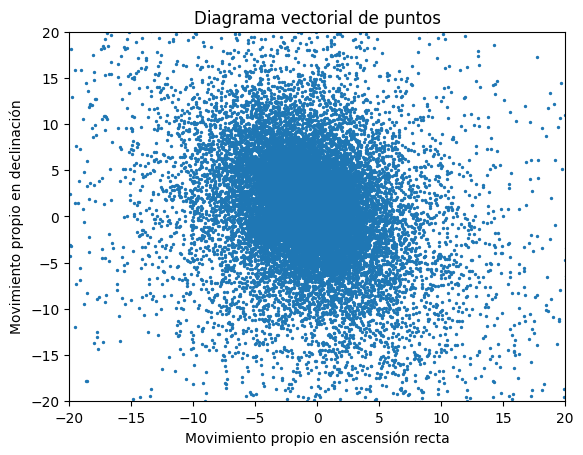

In [3]:
plt.scatter(data["pmra"], data["pmdec"], s=2)
plt.xlim(-20,20)
plt.ylim(-20,20)
plt.title("Diagrama vectorial de puntos")
plt.ylabel("Movimiento propio en declinación")
plt.xlabel("Movimiento propio en ascensión recta")

In [4]:
VPD = data[["pmra","pmdec"]].to_numpy()
VPD_error = data[["pmra_error","pmdec_error"]].to_numpy()

In [5]:
nc0 = 0.3155386081982841
nf0 = 1 - nc0

In [6]:
def estimate_membership(data, plot=False):
    """
    Estima los parámetros del modelo de mezcla bivariado y calcula la probabilidad
    de pertenencia al cúmulo para cada estrella.

    Parámetros
    ----------
    data : pandas.DataFrame
        Debe contener las columnas 'pmra' y 'pmdec' (movimientos propios en mas/yr).
    plot : bool, opcional
        Si es True, muestra un diagrama de dispersión coloreado por probabilidad
        y un histograma de probabilidades.

    Retorna
    -------
    data_out : pandas.DataFrame
        Copia del DataFrame original con una columna adicional 'P_cluster'.
    params_final : numpy.ndarray
        Vector con los nueve parámetros estimados en el orden:
        [μxf, μyf, sigmax, sigmay, μxc, μyc, sigma, nf, rho]
    """

    pmra = data['pmra'].values
    pmdec = data['pmdec'].values

    # ------------------------------------------------------------
    #1. Valores iniciales
    # ------------------------------------------------------------
    
    μxc = -4.3668
    μyc = -1.3399
    μxf = -0.7410
    μyf = 0.6275
    sigma = 0.2633               # desviación estándar común del cúmulo
    sigmax = 5.1546
    sigmay = 7.3140
    nf = nf0              # fracción de estrellas de campo - guess de TOPCAT
    rho = -0.2815   # coeficiente de correlación
    

    params_init = np.array([μxf, μyf, sigmax, sigmay, μxc, μyc, sigma, nf, rho])

    # ------------------------------------------------------------
    # 2. Maximización de la log‑verosimilitud
    # ------------------------------------------------------------
    def neg_log_likelihood(params, pmra, pmdec):
        μxf, μyf, sigmax, sigmay, μxc, μyc, sigma, nf, rho = params
        # Verificamos restricciones físicas
        if sigma <= 0 or sigmax <= 0 or sigmay <= 0 or nf < 0 or nf > 1 or rho < -1 or rho > 1:
            return 1e10

        # Densidad del cúmulo (circular)
        dxc = pmra - μxc
        dyc = pmdec - μyc
        cluster_dens = np.exp(-0.5 * (dxc**2 + dyc**2) / sigma**2) / (2 * np.pi * sigma**2)

        # Densidad del campo (elíptica)
        dxf = pmra - μxf
        dyf = pmdec - μyf
        q = dxf**2/sigmax**2 + dyf**2/sigmay**2 - 2*rho*dxf*dyf/(sigmax*sigmay)
        field_dens = np.exp(-0.5 * q / (1-rho**2)) / (2 * np.pi * sigmax * sigmay * np.sqrt(1-rho**2))

        # Mezcla
        mixture = (1 - nf) * cluster_dens + nf * field_dens
        # Evitamos log(0) añadiendo una pequeña constante
        log_mixture = np.log(mixture + 1e-300)
        return -np.sum(log_mixture)

    # Límites para los parámetros (sigma, sigmax, sigmay > 0; nf ∈ [0,1]; rho ∈ [-1,1])
    bounds = [(-np.inf, np.inf), (-np.inf, np.inf),
              (1e-6, np.inf), (1e-6, np.inf),
              (-np.inf, np.inf), (-np.inf, np.inf),
              (1e-6, np.inf), (0, 1), (-1, 1)]

    result = minimize(neg_log_likelihood, params_init, args=(pmra, pmdec),
                      method='L-BFGS-B', bounds=bounds)

    if result.success:
        params_final = result.x
    else:
        print("Advertencia: la optimización no convergió. Se usarán los valores iniciales.")
        params_final = params_init

    μxf, μyf, sigmax, sigmay, μxc, μyc, sigma, nf, rho = params_final

    # ------------------------------------------------------------
    # 3. Cálculo de probabilidades de pertenencia
    # ------------------------------------------------------------
    dxc = pmra - μxc
    dyc = pmdec - μyc
    cluster_dens = np.exp(-0.5 * (dxc**2 + dyc**2) / sigma**2) / (2 * np.pi * sigma**2)

    dxf = pmra - μxf
    dyf = pmdec - μyf
    q = dxf**2/sigmax**2 + dyf**2/sigmay**2 - 2*rho*dxf*dyf/(sigmax*sigmay)
    field_dens = np.exp(-0.5 * q / (1-rho**2)) / (2 * np.pi * sigmax * sigmay * np.sqrt(1-rho**2))

    total_dens = (1 - nf) * cluster_dens + nf * field_dens
    P_cluster = (1 - nf) * cluster_dens / total_dens

    data_out = data.copy()
    data_out['P_cluster'] = P_cluster

    # ------------------------------------------------------------
    # 4. Gráficos opcionales
    # ------------------------------------------------------------
    if plot:
        plt.figure(figsize=(14, 5))

        plt.subplot(1, 2, 1)
        sc = plt.scatter(pmra, pmdec, c=P_cluster, cmap='viridis',
                         s=5, alpha=0.6, edgecolors='none')
        plt.colorbar(sc, label='$P_{\\mathrm{cúmulo}}$')
        plt.xlabel('$\\mu_\\alpha$ (mas/yr)')
        plt.ylabel('$\\mu_\\delta$ (mas/yr)')
        plt.xlim(-20,20)
        plt.ylim(-20,20)
        plt.title('Diagrama de movimientos propios')

        plt.subplot(1, 2, 2)
        plt.hist(P_cluster, bins=50, range=(0, 1), color='steelblue', edgecolor='black', log=True)
        plt.xlabel('$P_{\\mathrm{cúmulo}}$')
        plt.ylabel('Número de estrellas')
        plt.title('Histograma de probabilidades')

        plt.tight_layout()
        plt.show()

    return data_out, params_final

C:\Users\japar\AppData\Local\Temp\ipykernel_24568\3517724601.py:99: RuntimeWarning: invalid value encountered in divide
  P_cluster = (1 - nf) * cluster_dens / total_dens


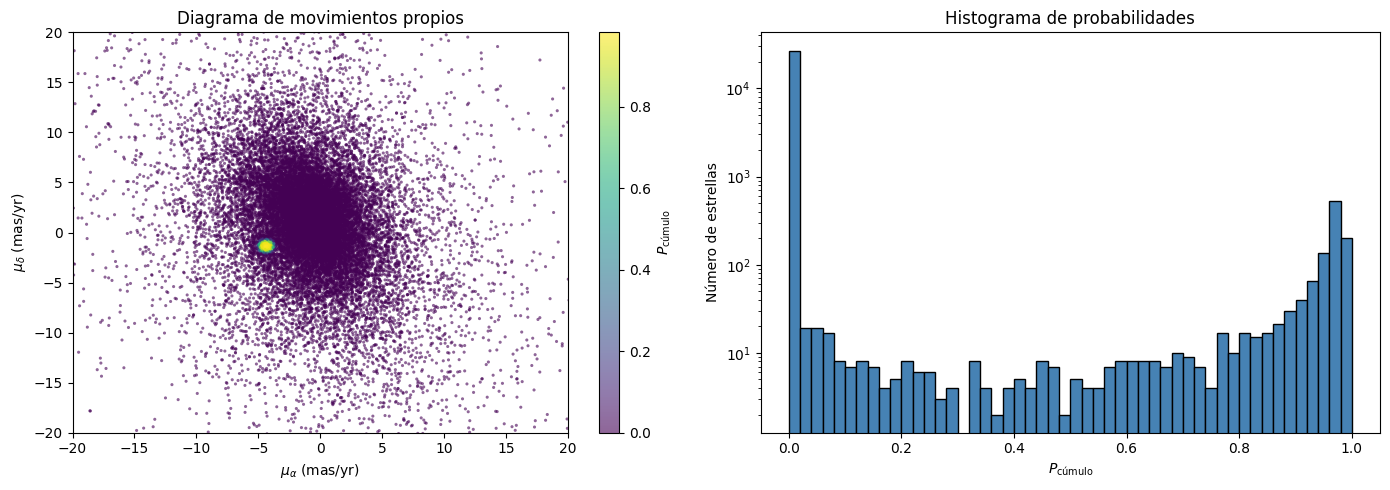


Parámetros estimados:
+-----------+----------+----------+----------+-----------+-----------+----------+----------+-----------+
|       μxf |      μyf |       σx |       σy |       μxc |       μyc |        σ |       nf |         ρ |
+===========+==========+==========+==========+===========+===========+==========+==========+===========+
| -0.629317 | 0.756004 | 5.804663 | 8.449119 | -4.368725 | -1.345637 | 0.217275 | 0.960058 | -0.308565 |
+-----------+----------+----------+----------+-----------+-----------+----------+----------+-----------+


In [7]:
data_con_prob, params = estimate_membership(data, plot=True)

headers = ['μxf', 'μyf', 'σx', 'σy', 'μxc', 'μyc', 'σ', 'nf', 'ρ']
print("\nParámetros estimados:")
print(tabulate([params], headers=headers, tablefmt='grid', floatfmt='.6f'))